In [1]:
# IMPORT LIBRARY
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pickle
import random


from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import jaccard_score

from sklearn.metrics import confusion_matrix

from sklearn.model_selection import cross_val_score

from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix)

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [2]:
# LOAD DATASET

# Dataset Random Forest
rf = pd.read_csv("dataset/DataReproduksiMendeley12.csv")

# Dataset Rekomendasi
rekom = pd.read_excel("dataset/data_rekomendasi_indo_1308(2).xlsx")

print("Dataset RF :", rf.shape)
print("Dataset Rekomendasi :", rekom.shape)

Dataset RF : (5432, 45)
Dataset Rekomendasi : (61, 58)


In [3]:
# CEK DATASET
print(rf.head())

print()


print()

print(rekom.head())

             diseases  anxiety and nervousness  depression  \
0  atrophic vaginitis                        0           0   
1  atrophic vaginitis                        0           0   
2  atrophic vaginitis                        0           0   
3  atrophic vaginitis                        0           0   
4  atrophic vaginitis                        0           0   

   depressive or psychotic symptoms  suprapubic pain  drug abuse  \
0                                 0                1           0   
1                                 0                0           0   
2                                 0                1           0   
3                                 0                1           0   
4                                 0                0           0   

   sharp abdominal pain  vomiting  headache  nausea  ...  \
0                     0         0         0       0  ...   
1                     0         0         0       0  ...   
2                     0         0     

In [4]:
# PREPROCESSING RANDOM FOREST
X = rf.drop(columns=["diseases"])

y = rf["diseases"]

print("Jumlah Data :", len(rf))
print("Jumlah Fitur :", X.shape[1])
print("Jumlah Kelas :", y.nunique())

print()
print(y.value_counts())

Jumlah Data : 5432
Jumlah Fitur : 44
Jumlah Kelas : 12

diseases
vaginal cyst                          1215
vaginitis                              909
vaginal yeast infection                608
postpartum depression                  494
idiopathic absence of menstruation     493
uterine fibroids                       450
endometriosis                          378
atrophic vaginitis                     329
polycystic ovarian syndrome (pcos)     268
premenstrual tension syndrome          137
idiopathic nonmenstrual bleeding        98
mittelschmerz                           53
Name: count, dtype: int64


In [5]:
# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X Train :", X_train.shape)
print("X Test  :", X_test.shape)

print("Y Train :", y_train.shape)
print("Y Test  :", y_test.shape)

X Train : (4345, 44)
X Test  : (1087, 44)
Y Train : (4345,)
Y Test  : (1087,)


In [6]:
# RANDOM FOREST
model = RandomForestClassifier(n_estimators=100, criterion="gini", max_depth=20, random_state=42, n_jobs=-1)

model.fit(X_train, y_train)

print("Model berhasil dilatih.")

Model berhasil dilatih.


In [7]:
#CROSS VALIDATION
cv_scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")

print("Accuracy tiap fold:")
for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print("\nRata-rata Accuracy :", np.mean(cv_scores))
print("Standar Deviasi    :", np.std(cv_scores))

Accuracy tiap fold:
Fold 1: 0.9632
Fold 2: 0.9632
Fold 3: 0.9604
Fold 4: 0.9622
Fold 5: 0.9595

Rata-rata Accuracy : 0.961707844761716
Standar Deviasi    : 0.0015095187835408959


In [8]:
# FEATURE IMPORTANCE

# Mengambil nilai importance dari Random Forest
importance = pd.DataFrame({"Feature": X_train.columns, "Importance": model.feature_importances_ })

# Urutkan dari yang terbesar
importance = importance.sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("="*60)
print("FEATURE IMPORTANCE")
print("="*60)

display(importance.head(10))


FEATURE IMPORTANCE


,Feature,Importance
0,pain during intercourse,0.071928
1,involuntary urination,0.053281
2,blood clots during menstrual periods,0.052261
3,hot flashes,0.047123
4,spotting or bleeding during pregnancy,0.042912
5,blood in urine,0.037667
6,suprapubic pain,0.036354
7,drug abuse,0.035814
8,cramps and spasms,0.033504
9,vulvar irritation,0.032338


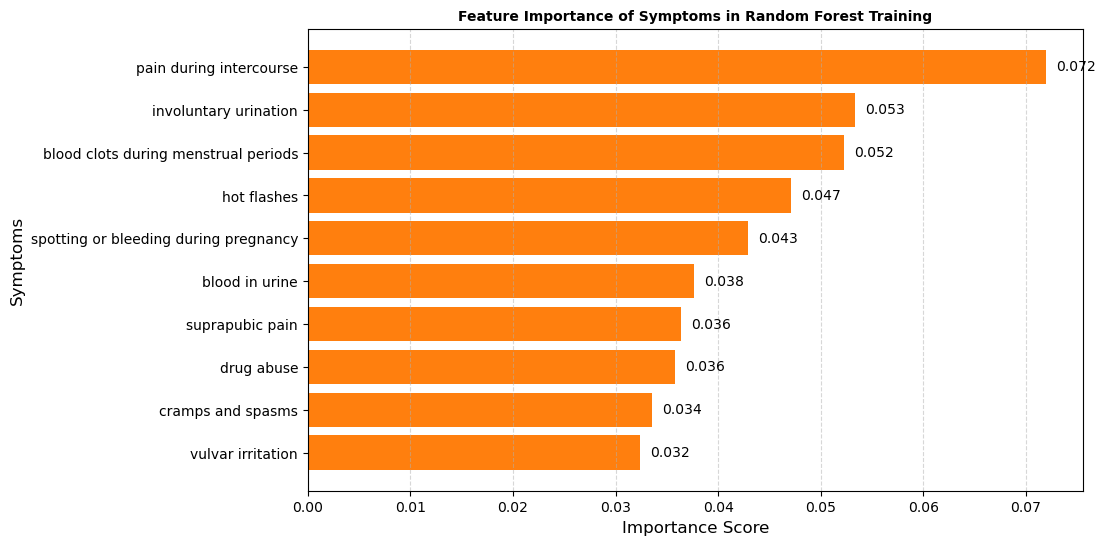

In [9]:
# GRAFIK FEATURE IMPORTANCE
plt.figure(figsize=(10,6))

plt.barh(importance["Feature"][:10], importance["Importance"][:10])

plt.gca().invert_yaxis()

plt.title("Feature Importance of Symptoms in Random Forest Training", fontsize=10, fontweight="bold")

plt.xlabel("Importance Score", fontsize=12)

plt.ylabel("Symptoms", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

bars = plt.barh(importance["Feature"][:10], importance["Importance"][:10])

for bar in bars:
    width = bar.get_width()

    plt.text(width + 0.001, bar.get_y() + bar.get_height()/2, f"{width:.3f}", va="center")

plt.show()

In [10]:
# EVALUASI MODEL
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

print()

print(classification_report(y_test, y_pred))

Accuracy : 0.9558417663293468

                                    precision    recall  f1-score   support

                atrophic vaginitis       0.98      0.95      0.97        66
                     endometriosis       0.96      0.95      0.95        76
idiopathic absence of menstruation       0.98      1.00      0.99        99
  idiopathic nonmenstrual bleeding       0.95      1.00      0.97        19
                     mittelschmerz       1.00      0.90      0.95        10
polycystic ovarian syndrome (pcos)       1.00      0.96      0.98        54
             postpartum depression       1.00      0.99      0.99        99
     premenstrual tension syndrome       1.00      1.00      1.00        27
                  uterine fibroids       0.97      0.98      0.97        90
                      vaginal cyst       0.97      1.00      0.98       243
           vaginal yeast infection       0.87      0.89      0.88       122
                         vaginitis       0.92      0.89 

In [11]:
print("RF Training Accuracy:", model.score(X_train, y_train))
print("RF Testing Accuracy:", model.score(X_test, y_test))

RF Training Accuracy: 0.9864211737629459
RF Testing Accuracy: 0.9558417663293468


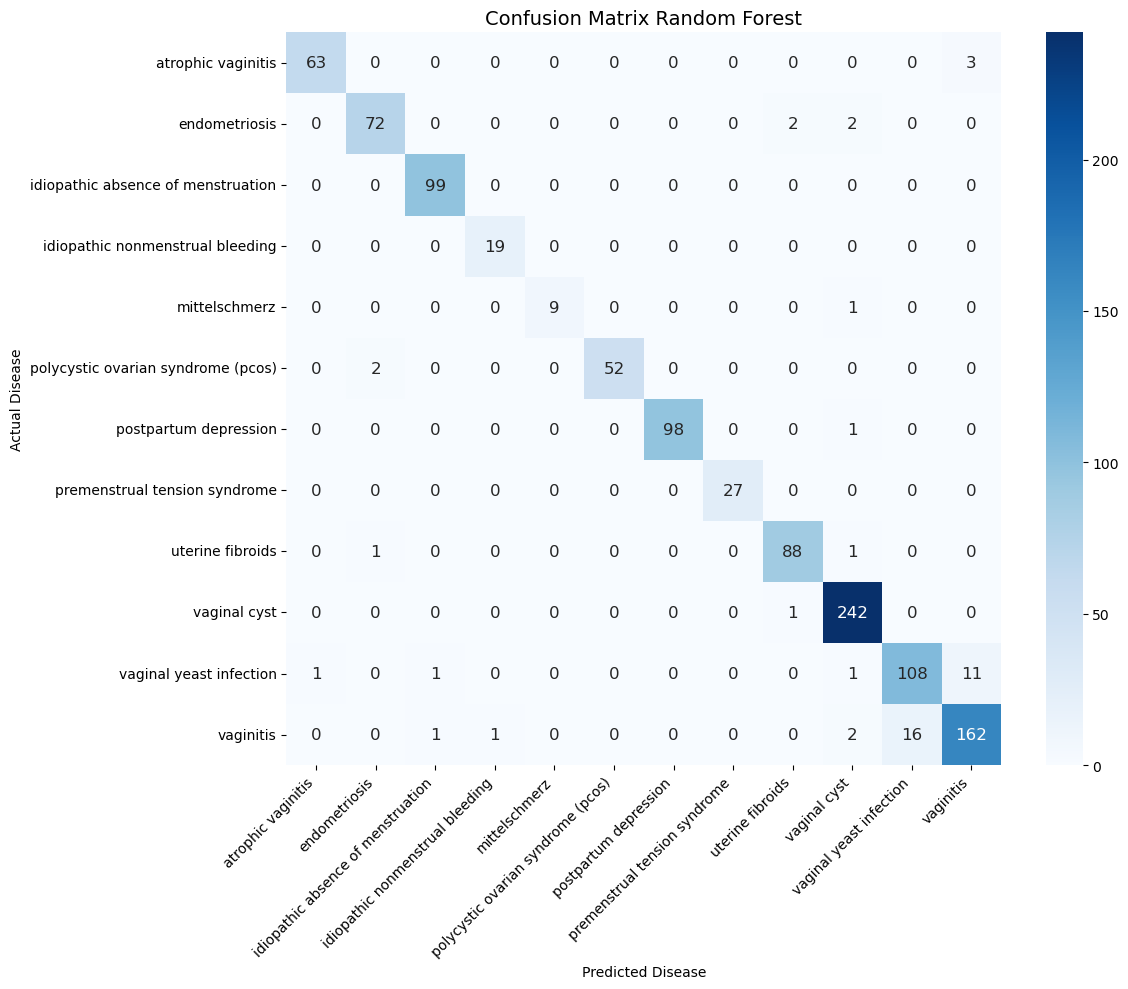

In [12]:
# CONFUSION MATRIX RANDOM FOREST

cm = confusion_matrix(y_test, y_pred)

class_names = model.classes_

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={"size": 12}
)

plt.title("Confusion Matrix Random Forest", fontsize=14)
plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [13]:
# MAPPING GEJALA
mapping_gejala = {}

for kolom in X.columns:
    mapping_gejala[kolom.lower()] = kolom
print("Jumlah fitur RF :", len(mapping_gejala))

Jumlah fitur RF : 44


In [14]:
# MAPPING GEJALA
# ============================================================
# Nama internal untuk Random Forest tetap menggunakan nama fitur
# asli dari dataset RF (English).
#
# Nama pada tampilan user menggunakan Bahasa Indonesia.
# Penting: "Gatal pada Kulit" hanya nama tampilan. Secara internal
# tetap dipetakan ke fitur RF "itching_of_skin" dan kolom CBF
# "Gatal_Kulit".
# ============================================================

mapping_cbf = {
    "suprapubic_pain": "Nyeri_Suprapubik",
    "vaginal_itching": "Gatal_Vagina",
    "painful_urination": "Nyeri_Saat_BAK",
    "involuntary_urination": "Inkontinensia_Urin",
    "pain_during_intercourse": "Nyeri_Saat_Berhubungan_Seksual",
    "frequent_urination": "Sering_BAK",
    "vaginal_discharge": "Keputihan",
    "blood_in_urine": "Darah_Dalam_Urine",
    "sharp_abdominal_pain": "Nyeri_Tajam_Pada_Perut",
    "lower_abdominal_pain": "Nyeri_Perut_Bagian_Bawah",
    "pain_during_pregnancy": "Nyeri_Selama_Kehamilan",
    "pelvic_pain": "Nyeri_Panggul",
    "vaginal_pain": "Nyeri_Pada_Vagina",
    "vaginal_redness": "Kemerahan_Pada_Vagina",
    "anxiety_and_nervousness": "Kecemasan_Dan_Kegelisahan",
    "depression": "Depresi",
    "depressive_or_psychotic_symptoms": "Gejala_Depresi_Atau_Psikosis",
    "drug_abuse": "Penyalahgunaan_Narkoba",
    "intermenstrual_bleeding": "Perdarahan_Antar_Menstruasi",
    "excessive_anger": "Kemarahan_Berlebihan",
    "problems_during_pregnancy": "Masalah_Selama_Kehamilan",
    "delusions_or_hallucinations": "Waham_Atau_Halusinasi",
    "cramps_and_spasms": "Kram_Dan_Kejang",
    "unpredictable_menstruation": "Menstruasi_Tidak_Teratur",
    "painful_menstruation": "Nyeri_Haid",
    "long_menstrual_periods": "Menstruasi_Berkepanjangan",
    "itching_of_skin": "Gatal_Kulit",
    "hot_flashes": "Rasa_Panas_Mendadak",
    "spotting_or_bleeding_during_pregnancy": "Bercak_Atau_Perdarahan_Saat_Kehamilan",
    "blood_clots_during_menstrual_periods": "Gumpalan_Darah_Saat_Menstruasi",
    "absence_of_menstruation": "Tidak_Menstruasi",
    "back_pain": "Nyeri_Punggung",
    "burning_abdominal_pain": "Nyeri_Perut_Seperti_Terbakar",
    "diarrhea": "Diare",
    "headache": "Sakit_Kepala",
    "heartburn": "Rasa_Terbakar_Di_Dada",
    "heavy_menstrual_flow": "Perdarahan_Antar_Menstruasi",
    "infertility": "Infertilitas",
    "nausea": "Mual",
    "pain_or_soreness_of_breast": "Nyeri_Atau_Rasa_Sakit_Pada_Payudara",
    "premenstrual_tension_or_irritability": "Ketegangan_atau_Mudah_Marah",
    "vomiting": "Muntah",
    "vulvar_irritation": "Iritasi_Vulva",
    "weight_gain": "Kenaikan_berat_badan"
}

# Label tampilan yang memang ingin digunakan.
# Internal tetap tidak berubah.
label_tampilan = {
    "Gatal_Kulit": "Gatal pada Kulit"
}

# English feature -> nama kolom Indonesia untuk CBF
mapping_tampilan_gejala = {}

for feature in X.columns:
    key = feature.replace(" ", "_").lower()
    nama_cbf = mapping_cbf.get(key)

    if nama_cbf is None:
        # Jika belum ada mapping, tampilkan nama fitur RF apa adanya.
        nama_cbf = feature

    mapping_tampilan_gejala[feature] = label_tampilan.get(
        nama_cbf,
        str(nama_cbf).replace("_", " ")
    )

print("Jumlah fitur RF:", len(X.columns))
print("Jumlah mapping gejala:", len(mapping_tampilan_gejala))

# Validasi khusus Gatal pada Kulit.
if "itching_of_skin" in X.columns:
    print("✓ itching_of_skin ->", mapping_cbf.get("itching_of_skin"))
else:
    print("WARNING: fitur 'itching_of_skin' tidak ditemukan pada dataset RF.")

if "Gatal_Kulit" in rekom.columns:
    print("✓ Kolom CBF 'Gatal_Kulit' ditemukan.")
else:
    print("WARNING: kolom 'Gatal_Kulit' tidak ditemukan pada dataset rekomendasi.")


Jumlah fitur RF: 44
Jumlah mapping gejala: 44
✓ Kolom CBF 'Gatal_Kulit' ditemukan.


In [15]:
# DAFTAR GEJALA UNTUK INPUT MANUAL
# ============================================================
# english_gejala = nama fitur internal RF
# gejala_tampilan_indo = nama yang ditampilkan ke user
# ============================================================

english_gejala = []
gejala_tampilan_indo = []

for col in X.columns:
    nama_indo = mapping_tampilan_gejala.get(col, str(col).replace("_", " "))

    # Hanya tampilkan gejala yang juga memiliki kolom pada dataset CBF.
    key = col.replace(" ", "_").lower()
    nama_cbf = mapping_cbf.get(key)

    if nama_cbf in rekom.columns:
        english_gejala.append(col)
        gejala_tampilan_indo.append(str(nama_indo))
    else:
        print(f"WARNING: {col} -> {nama_cbf} tidak ditemukan di dataset rekomendasi.")

print("Jumlah gejala yang tersedia:", len(english_gejala))

# Validasi bahwa Gatal pada Kulit benar-benar masuk daftar input.
if "itching_of_skin" in english_gejala:
    idx_gatal = english_gejala.index("itching_of_skin") + 1
    print(f"✓ Gatal pada Kulit tersedia pada nomor {idx_gatal}.")
else:
    print("WARNING: 'Gatal pada Kulit' tidak masuk daftar input.")


Jumlah gejala yang tersedia: 44


In [16]:
# INPUT USER
print("="*60)
print("SISTEM REKOMENDASI KESEHATAN REPRODUKSI")
print("="*60)

nama = input("Nama : ").strip()

while True:
    try:
        umur = int(input("Umur : "))
        break
    except ValueError:
        print("Umur harus berupa angka.")

print()
print("="*60)
print("DAFTAR GEJALA")
print("="*60)

for i, gejala_indo in enumerate(gejala_tampilan_indo, start=1):
    # Tampilkan nama Indonesia; nilai internal tetap English.
    print(f"{i}. {gejala_indo}")

print()
print("Masukkan nomor gejala yang dialami.")
print("Jika lebih dari satu, pisahkan dengan koma. Contoh: 1,3,7")

while True:
    pilihan = input("\nNomor gejala : ").strip()

    try:
        nomor = [int(x.strip()) for x in pilihan.split(",") if x.strip()]

        if len(nomor) == 0:
            print("Pilih minimal satu gejala.")
            continue

        if any(i < 1 or i > len(english_gejala) for i in nomor):
            print(f"Nomor harus berada di antara 1 sampai {len(english_gejala)}.")
            continue

        # Hilangkan nomor duplikat tetapi pertahankan urutan.
        nomor = list(dict.fromkeys(nomor))
        break

    except ValueError:
        print("Format salah. Contoh input: 1,3,7")

# Internal: nama fitur English untuk Random Forest.
gejala_user = [english_gejala[i-1] for i in nomor]

# Tampilan: nama gejala Indonesia.
gejala_user_indo = [gejala_tampilan_indo[i-1] for i in nomor]

print()
print("Gejala yang dipilih:")
for g in gejala_user_indo:
    print("✓", g)


SISTEM REKOMENDASI KESEHATAN REPRODUKSI


Nama :  buhun
Umur :  20



DAFTAR GEJALA
1. Kecemasan Dan Kegelisahan
2. Depresi
3. Gejala Depresi Atau Psikosis
4. Nyeri Suprapubik
5. Penyalahgunaan Narkoba
6. Nyeri Tajam Pada Perut
7. Muntah
8. Sakit Kepala
9. Mual
10. Diare
11. Gatal Vagina
12. Nyeri Saat BAK
13. Inkontinensia Urin
14. Nyeri Saat Berhubungan Seksual
15. Sering BAK
16. Nyeri Perut Bagian Bawah
17. Keputihan
18. Darah Dalam Urine
19. Rasa Panas Mendadak
20. Perdarahan Antar Menstruasi
21. Nyeri Punggung
22. Nyeri Selama Kehamilan
23. Nyeri Panggul
24. Nyeri Perut Seperti Terbakar
25. Kenaikan berat badan
26. Rasa Terbakar Di Dada
27. Nyeri Pada Vagina
28. Kemerahan Pada Vagina
29. Iritasi Vulva
30. Kemarahan Berlebihan
31. Masalah Selama Kehamilan
32. Bercak Atau Perdarahan Saat Kehamilan
33. Kram Dan Kejang
34. Waham Atau Halusinasi
35. Nyeri Atau Rasa Sakit Pada Payudara
36. Gumpalan Darah Saat Menstruasi
37. Tidak Menstruasi
38. Menstruasi Berkepanjangan
39. Perdarahan Antar Menstruasi
40. Menstruasi Tidak Teratur
41. Nyeri Haid
42. Infer


Nomor gejala :  43



Gejala yang dipilih:
✓ Gatal pada Kulit


In [17]:
# VECTOR USER
# ============================================================
# Gunakan nama fitur RF secara langsung.
# Jadi input "Gatal pada Kulit" -> "itching_of_skin"
# dan tidak bergantung pada pencocokan nama tampilan.
# ============================================================

user_vector = pd.DataFrame(
    np.zeros((1, X.shape[1]), dtype=int),
    columns=X.columns
)

for g in gejala_user:
    if g in user_vector.columns:
        user_vector.loc[0, g] = 1
    else:
        print(f"WARNING: fitur RF '{g}' tidak ditemukan.")

print()
print("Jumlah gejala aktif :", int(user_vector.sum(axis=1).iloc[0]))

# Debug khusus untuk Gatal pada Kulit
if "itching_of_skin" in gejala_user:
    print("✓ User vector: itching_of_skin =",
          int(user_vector.loc[0, "itching_of_skin"]))



Jumlah gejala aktif : 1


In [18]:
# PREDIKSI RANDOM FOREST
# Mapping nama penyakit untuk tampilan Bahasa Indonesia.
# Digunakan hanya untuk tampilan; nilai internal model tetap English.
mapping_penyakit_tampilan = {
    "atrophic vaginitis": "Vaginitis Atrofi",
    "endometriosis": "Endometriosis",
    "idiopathic absence of menstruation": "Amenore Idiopatik",
    "idiopathic nonmenstrual bleeding": "Perdarahan Di Luar Menstruasi",
    "mittelschmerz": "Nyeri Ovulasi",
    "polycystic ovarian syndrome (pcos)": "PCOS",
    "postpartum depression": "Depresi Pascamelahirkan",
    "premenstrual tension syndrome": "PMS",
    "uterine fibroids": "Miom Rahim",
    "vaginal cyst": "Kista Vagina",
    "vaginal yeast infection": "Infeksi Jamur Vagina",
    "vaginitis": "Peradangan Atau Infeksi Vagina"
}


prob = model.predict_proba(user_vector)[0]

kelas = model.classes_

hasil_prediksi = pd.DataFrame({"Penyakit": kelas, "Probabilitas": prob})

hasil_prediksi = hasil_prediksi.sort_values(by="Probabilitas", ascending=False).reset_index(drop=True)


# THRESHOLD RANDOM FOREST
THRESHOLD_PROB = 0.05   # 5%

top3 = hasil_prediksi[hasil_prediksi["Probabilitas"] >= THRESHOLD_PROB].head(3).copy()


print("="*60)
print("TOP 3 PREDIKSI PENYAKIT")
print("="*60)

if len(top3) == 0:

    print("Tidak ada penyakit yang memenuhi")
    print(f"threshold probabilitas {THRESHOLD_PROB*100:.0f}%.")

else:

    for i, row in top3.reset_index(drop=True).iterrows():

        penyakit_tampil = mapping_penyakit_tampilan.get(row["Penyakit"], row["Penyakit"])
        penyakit_tampil = str(penyakit_tampil).replace("_", " ")
        print(f"{i+1}. {penyakit_tampil} " f"({row['Probabilitas']*100:.2f}%)")


print("-"*60)
print("CATATAN")
print("-"*60)

print("Hasil ini merupakan keluaran sistem dan bukan pengganti diagnosis medis profesional.")

TOP 3 PREDIKSI PENYAKIT
1. Infeksi Jamur Vagina (61.60%)
2. Amenore Idiopatik (6.49%)
3. Kista Vagina (6.25%)
------------------------------------------------------------
CATATAN
------------------------------------------------------------
Hasil ini merupakan keluaran sistem dan bukan pengganti diagnosis medis profesional.


In [19]:
# SIMILARITY GEJALA
hasil_similarity = []

# Ambil semua fitur TANPA kolom diseases
fitur = X.columns

for _, row in rf.iterrows():

    penyakit = row["diseases"]

    disease_vector = row[fitur].values.astype(int)

    score = jaccard_score(user_vector.iloc[0].astype(int), disease_vector)

    hasil_similarity.append({"Penyakit": penyakit, "Similarity_Gejala": score})

similarity_df = pd.DataFrame(hasil_similarity)

similarity_df = similarity_df.sort_values(by="Similarity_Gejala", ascending=False).reset_index(drop=True)

print("="*60)
print("SYMPTOMS SIMILARITY")
print("="*60)

# RATA-RATA SIMILARITY PER PENYAKIT
similarity_df = similarity_df.groupby("Penyakit", as_index=False).agg({"Similarity_Gejala":"mean"})

display(similarity_df)

SYMPTOMS SIMILARITY


,Penyakit,Similarity_Gejala
0,atrophic vaginitis,0.000000
1,endometriosis,0.000000
2,idiopathic absence of menstruation,0.000000
3,idiopathic nonmenstrual bleeding,0.000000
4,mittelschmerz,0.000000
5,polycystic ovarian syndrome (pcos),0.000000
6,postpartum depression,0.000000
7,premenstrual tension syndrome,0.000000
8,uterine fibroids,0.000000
9,vaginal cyst,0.000000


In [20]:
# GABUNGKAN SIMILARITY DENGAN HASIL TOP PENYAKIT

top3 = top3.merge(similarity_df, on="Penyakit", how="left")

print("="*60)
print("TOP 3 PENYAKIT DENGAN KEMIRIPAN GEJALA")
print("="*60)

# Dataframe khusus tampilan.
# Kolom internal tetap menggunakan nama English agar proses berikutnya
# tetap kompatibel dengan mapping dan model.
top3_tampil = top3[["Penyakit", "Probabilitas", "Similarity_Gejala"]].copy()

top3_tampil["Penyakit"] = top3_tampil["Penyakit"].map(
    mapping_penyakit_tampilan
).fillna(top3_tampil["Penyakit"])

top3_tampil = top3_tampil.rename(columns={
    "Penyakit": "Penyakit",
    "Probabilitas": "Probabilitas",
    "Similarity_Gejala": "Kemiripan_Gejala"
})

display(top3_tampil)


TOP 3 PENYAKIT DENGAN KEMIRIPAN GEJALA


,Penyakit,Probabilitas,Kemiripan_Gejala
0,Infeksi Jamur Vagina,0.615977,0.099473
1,Amenore Idiopatik,0.064922,0.000000
2,Kista Vagina,0.062500,0.000000


In [21]:
# MAPPING PENYAKIT
# Hasil Random Forest tetap menggunakan nama penyakit English.
# Dataset rekomendasi Indonesia menggunakan nama kolom penyakit berikut.

mapping_penyakit = {
    "atrophic vaginitis": "Vaginitis_Atrofi",
    "endometriosis": "Endometriosis",
    "idiopathic absence of menstruation": "Amenore_Idiopatik",
    "idiopathic nonmenstrual bleeding": "Perdarahan_Di_Luar_Menstruasi",
    "mittelschmerz": "Nyeri_Ovulasi",
    "polycystic ovarian syndrome (pcos)": "PCOS",
    "postpartum depression": "Depresi_Pascamelahirkan",
    "premenstrual tension syndrome": "PMS",
    "uterine fibroids": "Miom_Rahim",
    "vaginal cyst": "Kista_Vagina",
    "vaginal yeast infection": "Infeksi_Jamur_Vagina",
    "vaginitis": "Peradangan_Atau_Infeksi_Vagina"
}


In [22]:
# SIAPKAN SELURUH REKOMENDASI
rekom_filter = rekom.copy()

# INFORMASI PENYAKIT TOP 3
penyakit_top3 = top3["Penyakit"].tolist()

prob_top3 = top3["Probabilitas"].tolist()

similarity_top3 = top3["Similarity_Gejala"].tolist()


# Dictionary probabilitas
probabilitas_penyakit = dict(zip(penyakit_top3, prob_top3))


# Dictionary similarity penyakit
similarity_penyakit = dict(zip(penyakit_top3, similarity_top3))

# CARI PENYAKIT YANG MENDUKUNG SETIAP REKOMENDASI
daftar_penyakit = []
daftar_probabilitas = []
daftar_similarity_gejala = []


for _, row in rekom_filter.iterrows():
    penyakit_pendukung = []
    probabilitas_pendukung = []
    similarity_pendukung = []


    for penyakit in penyakit_top3:
        if penyakit not in mapping_penyakit:
            continue
        kolom = mapping_penyakit[penyakit]

        if (kolom in rekom.columns and row[kolom] == 1):

            penyakit_pendukung.append(penyakit)

            probabilitas_pendukung.append(probabilitas_penyakit[penyakit])

            similarity_pendukung.append(similarity_penyakit[penyakit])


    daftar_penyakit.append(penyakit_pendukung)

    daftar_probabilitas.append(probabilitas_pendukung)

    daftar_similarity_gejala.append(similarity_pendukung)


# MASUKKAN KE DATAFRAME
rekom_filter["Penyakit"] = daftar_penyakit

rekom_filter["Probabilitas"] = daftar_probabilitas

rekom_filter["Similarity_Gejala"] = (daftar_similarity_gejala)


print("="*60)
print("SELURUH REKOMENDASI SEBAGAI KANDIDAT CBF")
print("="*60)

print("Jumlah seluruh rekomendasi :", len(rekom_filter))

SELURUH REKOMENDASI SEBAGAI KANDIDAT CBF
Jumlah seluruh rekomendasi : 61


In [23]:
# MAPPING CBF GEJALA
# mapping_cbf sudah didefinisikan sebelum input agar daftar gejala manual dapat ditampilkan.
print("Jumlah mapping CBF:", len(mapping_cbf))


Jumlah mapping CBF: 44


In [24]:
# FITUR CBF
# ============================================================
# gejala_user berisi nama fitur English internal.
# mapping_cbf mengubahnya menjadi nama kolom Indonesia.
# ============================================================

fitur_cbf = []

for g in gejala_user:
    key = g.replace(" ", "_").lower()
    kolom = mapping_cbf.get(key)

    if kolom is None:
        print(f"WARNING: Gejala '{g}' belum memiliki mapping CBF.")
        continue

    if kolom in rekom.columns:
        fitur_cbf.append(kolom)
    else:
        print(f"WARNING: Kolom '{kolom}' tidak ditemukan di dataset rekomendasi.")

print("=" * 60)
print("CBF FEATURES")
print("=" * 60)
print("Gejala user (internal) :", gejala_user)
print("Gejala user (Indonesia):", gejala_user_indo)
print("Fitur CBF              :", fitur_cbf)
print("Jumlah fitur           :", len(fitur_cbf))

if "itching_of_skin" in gejala_user:
    print("✓ Gatal pada Kulit -> Gatal_Kulit berhasil masuk CBF.")


CBF FEATURES
Gejala user (internal) : ['itching of skin']
Gejala user (Indonesia): ['Gatal pada Kulit']
Fitur CBF              : ['Gatal_Kulit']
Jumlah fitur           : 1


In [25]:
print()
print("JUMLAH FITUR CBF :", len(fitur_cbf))

for fitur in fitur_cbf:
    print(fitur, "-> jumlah nilai 1:", int(rekom[fitur].fillna(0).astype(int).sum()))


JUMLAH FITUR CBF : 1
Gatal_Kulit -> jumlah nilai 1: 45


In [26]:
# JACCARD SIMILARITY
def jaccard_similarity(user, item):
    user = np.array(user).astype(int)
    item = np.array(item).astype(int)
    intersection = np.sum((user==1) & (item==1))
    union = np.sum((user==1) | (item==1))

    if union == 0:
        return 0
    return intersection/union

In [27]:
# CONTENT-BASED FILTERING
similarity = []

# USER VECTOR CBF
# ------------------------------------------------------------
# Karena fitur_cbf hanya berisi gejala yang dipilih user,
# setiap fitur pada user vector bernilai 1.

user_cbf = np.ones(len(fitur_cbf), dtype=int)

print("=" * 60)
print("USER CBF VECTOR")
print("=" * 60)

print("Fitur :", fitur_cbf)
print("Vector:", user_cbf)

# HITUNG SIMILARITY USER VS RECOMMENDATION
for _, row in rekom_filter.iterrows():

    item = (row[fitur_cbf].fillna(0).astype(int).values)

    score = jaccard_similarity(user_cbf, item)

    similarity.append(score)

# SIMPAN SIMILARITY
rekom_filter["Similarity"] = similarity

# CBF THRESHOLD
THRESHOLD_CBF = 0.25

rekom_filter = rekom_filter[rekom_filter["Similarity"] > THRESHOLD_CBF].copy()

print("=" * 60)
print("CONTENT-BASED FILTERING")
print("=" * 60)

print("CBF Similarity Threshold :", THRESHOLD_CBF)

print("Jumlah rekomendasi setelah CBF :", len(rekom_filter))

print()
print("REKOMENDASI YANG LOLOS CBF:")

display(rekom_filter[[
            "Kode_Rekomendasi",
            "Similarity"]].sort_values(by="Similarity", ascending=False))

USER CBF VECTOR
Fitur : ['Gatal_Kulit']
Vector: [1]
CONTENT-BASED FILTERING
CBF Similarity Threshold : 0.25
Jumlah rekomendasi setelah CBF : 8

REKOMENDASI YANG LOLOS CBF:


,Kode_Rekomendasi,Similarity
4,Tempelkan kompres dingin pada area yang gatal ...,1.0
5,Minum air putih lebih banyak dari biasanya,1.0
6,Jaga area kewanitaan tetap bersih dan kering,1.0
16,Gunakan pakaian dalam berbahan katun,1.0
17,Hindari sabun atau pembersih kewanitaan yang b...,1.0
32,Minum cetirizine untuk membantu mengurangi gat...,1.0
39,Periksa sampel cairan vagina,1.0
52,Konsumsi yogurt atau makanan fermentasi,1.0


In [28]:
# GABUNGKAN REKOMENDASI
hasil = []

for nama, grup in rekom_filter.groupby("Kode_Rekomendasi"):
    penyakit_pendukung = []
    probabilitas_pendukung = []
    similarity_gejala_pendukung = []

    for _, row in grup.iterrows():
        for i, penyakit in enumerate(row["Penyakit"]):

            if penyakit not in penyakit_pendukung:
                penyakit_pendukung.append(penyakit)

                probabilitas_pendukung.append(row["Probabilitas"][i])

                similarity_gejala_pendukung.append(row["Similarity_Gejala"][i])


    hasil.append({
        "Recommendations": nama,

        "Kategori": grup["Kategori"].iloc[0],

        "Similarity": grup["Similarity"].max(),

        "Similarity_Gejala": (max(similarity_gejala_pendukung) if similarity_gejala_pendukung else 0),

        "Penyakit": penyakit_pendukung,

        "Probabilitas": probabilitas_pendukung

    })


hasil = pd.DataFrame(hasil)

print("="*60)
print("RECOMMENDATIONS AFTER CBF FILTER")
print("="*60)

print("Jumlah rekomendasi :", len(hasil))

RECOMMENDATIONS AFTER CBF FILTER
Jumlah rekomendasi : 8


In [29]:
# HYBRID RECOMMENDATION SCORE
def mean_probability(probabilities):
    if len(probabilities) == 0:
        return 0.0

    return np.mean(probabilities)

# HITUNG RATA-RATA PROBABILITAS PENYAKIT
hasil["Mean_Probability"] = (hasil["Probabilitas"].apply(mean_probability))

# HYBRID SCORE
hasil["Skor_Relevansi"] = (0.7 * hasil["Similarity"] + 0.3 * hasil["Mean_Probability"])


print("="*60)
print("HYBRID RECOMMENDATION SCORE")
print("="*60)

display(
    hasil[[
            "Recommendations",
            "Similarity",
            "Mean_Probability",
            "Similarity_Gejala",
            "Skor_Relevansi"
        ]].sort_values(by="Skor_Relevansi", ascending=False))

HYBRID RECOMMENDATION SCORE


,Recommendations,Similarity,Mean_Probability,Similarity_Gejala,Skor_Relevansi
3,Konsumsi yogurt atau makanan fermentasi,1.0,0.615977,0.099473,0.884793
6,Periksa sampel cairan vagina,1.0,0.615977,0.099473,0.884793
0,Gunakan pakaian dalam berbahan katun,1.0,0.339239,0.099473,0.801772
1,Hindari sabun atau pembersih kewanitaan yang b...,1.0,0.339239,0.099473,0.801772
2,Jaga area kewanitaan tetap bersih dan kering,1.0,0.339239,0.099473,0.801772
4,Minum air putih lebih banyak dari biasanya,1.0,0.000000,0.000000,0.700000
5,Minum cetirizine untuk membantu mengurangi gat...,1.0,0.000000,0.000000,0.700000
7,Tempelkan kompres dingin pada area yang gatal ...,1.0,0.000000,0.000000,0.700000


In [30]:
# OUTPUT REKOMENDASI

# Urutan awal rekomendasi menggunakan Hybrid Score.
# Semua rekomendasi yang lolos CBF ditampilkan (tanpa Top-N).

hasil_tampil = hasil.sort_values(by="Skor_Relevansi", ascending=False).reset_index(drop=True)

medical = hasil_tampil[hasil_tampil["Kategori"] == "Medical Recommendation"].copy().reset_index(drop=True)

traditional = hasil_tampil[hasil_tampil["Kategori"] == "Traditional Recommendation"].copy().reset_index(drop=True)

print("\n" + "=" * 70)
print("GEJALA YANG DIPILIH")
print("=" * 70)

for i, symptom in enumerate(gejala_user_indo, start=1):
    print(f"{i}. {symptom}")

print("\n" + "=" * 70)
print("TOP 3 PREDIKSI PENYAKIT")
print("=" * 70)

for i, (_, row) in enumerate(top3.reset_index(drop=True).iterrows(), start=1):
    penyakit_indo = mapping_penyakit_tampilan.get(row["Penyakit"], row["Penyakit"])
    print(f"{i}. {penyakit_indo} ({row['Probabilitas'] * 100:.2f}%)")

print("\n" + "=" * 70)
print("REKOMENDASI MEDIS")
print("=" * 70)

if len(medical) == 0:
    print("Tidak ada rekomendasi medis yang lolos CBF.")
else:
    for i, (_, row) in enumerate(medical.iterrows(), start=1):
        print(f"{i}. {row['Recommendations']}")

print("\n" + "=" * 70)
print("REKOMENDASI TRADISIONAL")
print("=" * 70)

if len(traditional) == 0:
    print("Tidak ada rekomendasi tradisional yang lolos CBF.")
else:
    for i, (_, row) in enumerate(traditional.iterrows(), start=1):
        print(f"{i}. {row['Recommendations']}")



GEJALA YANG DIPILIH
1. Gatal pada Kulit

TOP 3 PREDIKSI PENYAKIT
1. Infeksi Jamur Vagina (61.60%)
2. Amenore Idiopatik (6.49%)
3. Kista Vagina (6.25%)

REKOMENDASI MEDIS
1. Periksa sampel cairan vagina
2. Gunakan pakaian dalam berbahan katun
3. Hindari sabun atau pembersih kewanitaan yang berpewangi
4. Jaga area kewanitaan tetap bersih dan kering
5. Minum air putih lebih banyak dari biasanya
6. Minum cetirizine untuk membantu mengurangi gatal karena alergi
7. Tempelkan kompres dingin pada area yang gatal atau bengkak

REKOMENDASI TRADISIONAL
1. Konsumsi yogurt atau makanan fermentasi


In [31]:
#### REINFORCEMENT LEARNING - FEEDBACK DAN Q-TABLE
ALPHA = 0.1
EPSILON = 0.1
Q_TABLE_FILE = "q_table_rf.pkl"  # DIUBAH PADA NOTEBOOK RF

# State = konteks 3 penyakit teratas
state = tuple(sorted(top3["Penyakit"].head(3).tolist()))

# Load Q-table dari feedback sebelumnya
if os.path.exists(Q_TABLE_FILE):
    with open(Q_TABLE_FILE, "rb") as f:
        q_table = pickle.load(f)
else:
    q_table = {}

q_table.setdefault(state, {})

# Setiap rekomendasi hasil CBF menjadi action
for action in hasil_tampil["Recommendations"].tolist():
    q_table[state].setdefault(action, 0.0)


# EPSILON-GREEDY
def epsilon_greedy_rank(df, q_values, epsilon=0.1):
    remaining = list(df["Recommendations"])
    ranked = []

    while remaining:
        q_remaining = [q_values.get(action, 0.0) for action in remaining]

        # Exploration
        if random.random() < epsilon:
            action = random.choice(remaining)

        # Exploitation
        else:
            max_q = max(q_remaining)
            candidates = [action for action in remaining if q_values.get(action, 0.0) == max_q]

            # Jika semua Q masih 0, gunakan Hybrid Score
            # agar urutan awal tidak acak.
            if max_q == 0.0:
                action = (df[df["Recommendations"].isin(candidates)].sort_values("Skor_Relevansi", ascending=False).iloc[0]["Recommendations"])
            else:
                action = random.choice(candidates)

        ranked.append(action)
        remaining.remove(action)

    return (df.set_index("Recommendations").loc[ranked].reset_index())

# Tentukan urutan action menggunakan epsilon-greedy.
# HASIL INI HANYA MENENTUKAN URUTAN RATING,
# bukan mengubah daftar rekomendasi yang ditampilkan.
hasil_rating = epsilon_greedy_rank(hasil_tampil.copy(), q_table[state], EPSILON)

print("\n" + "=" * 70)
print("RATING RECOMMENDATIONS")
print("=" * 70)
print("Silakan beri rating setiap rekomendasi dari 1 sampai 5.")
print("1 = sangat tidak sesuai")
print("2 = tidak sesuai")
print("3 = cukup sesuai")
print("4 = sesuai")
print("5 = sangat sesuai")

def rating_to_reward(rating):
    return {
        1: -1.0,
        2: -0.5,
        3: 0.0,
        4: 0.5,
        5: 1.0
    }[rating]


# USER FEEDBACK
feedback = []

for _, row in hasil_rating.iterrows():

    action = row["Recommendations"]

    while True:
        try:
            rating = int(input(f"\nRating for '{action}': "))

            if rating in [1, 2, 3, 4, 5]:
                break

            print("Rating must be from 1 to 5.")

        except ValueError:
            print("Please enter a number from 1 to 5.")

    reward = rating_to_reward(rating)

    old_q = q_table[state].get(action, 0.0)

    # One-step Q-learning:
    # Q <- Q + alpha * (reward - Q)
    new_q = old_q + ALPHA * (reward - old_q)

    q_table[state][action] = new_q

    feedback.append({
        "State": state,
        "Recommendation": action,
        "Rating": rating,
        "Reward": reward,
        "Q_Value": new_q
    })

# SIMPAN Q-TABLE
with open(Q_TABLE_FILE, "wb") as f:
    pickle.dump(q_table, f)

print("\n" + "=" * 70)
print("FEEDBACK SAVED")
print("=" * 70)
print(f"Q-table saved successfully to: {Q_TABLE_FILE}")
print(f"Number of feedback entries saved: {len(feedback)}")
# Data feedback pada run ini juga tersedia sebagai DataFrame
feedback_df = pd.DataFrame(feedback)

if len(feedback_df) > 0:
    display(feedback_df)


RATING RECOMMENDATIONS
Silakan beri rating setiap rekomendasi dari 1 sampai 5.
1 = sangat tidak sesuai
2 = tidak sesuai
3 = cukup sesuai
4 = sesuai
5 = sangat sesuai


KeyboardInterrupt: Interrupted by user